In [1]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [3]:
training_data = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv", index_col = 0)

In [4]:
training_data.head(10)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
id,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0
6,61574.16,0.042,696,16907.71,13.52,Other,Single,High School,Self-employed,Debt consolidation,C5,1.0
7,45953.31,0.100,654,10111.62,12.82,Female,Married,High School,Employed,Home,D1,1.0
8,30592.29,0.132,713,7522.36,9.48,Male,Married,Bachelor's,Employed,Education,C5,1.0


In [5]:
training_data.shape

(593994, 12)

In [6]:
training_data['loan_paid_back'].value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

In [7]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 58.9+ MB


In [8]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


In [9]:
training_data.describe(include='object').T

,count,unique,top,freq
gender,593994,3,Female,306175
marital_status,593994,4,Single,288843
education_level,593994,5,Bachelor's,279606
employment_status,593994,5,Employed,450645
loan_purpose,593994,8,Debt consolidation,324695
grade_subgrade,593994,30,C3,58695


In [10]:
training_data.isnull().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

array([[<Axes: title={'center': 'annual_income'}>,
        <Axes: title={'center': 'debt_to_income_ratio'}>],
       [<Axes: title={'center': 'credit_score'}>,
        <Axes: title={'center': 'loan_amount'}>],
       [<Axes: title={'center': 'interest_rate'}>,
        <Axes: title={'center': 'loan_paid_back'}>]], dtype=object)

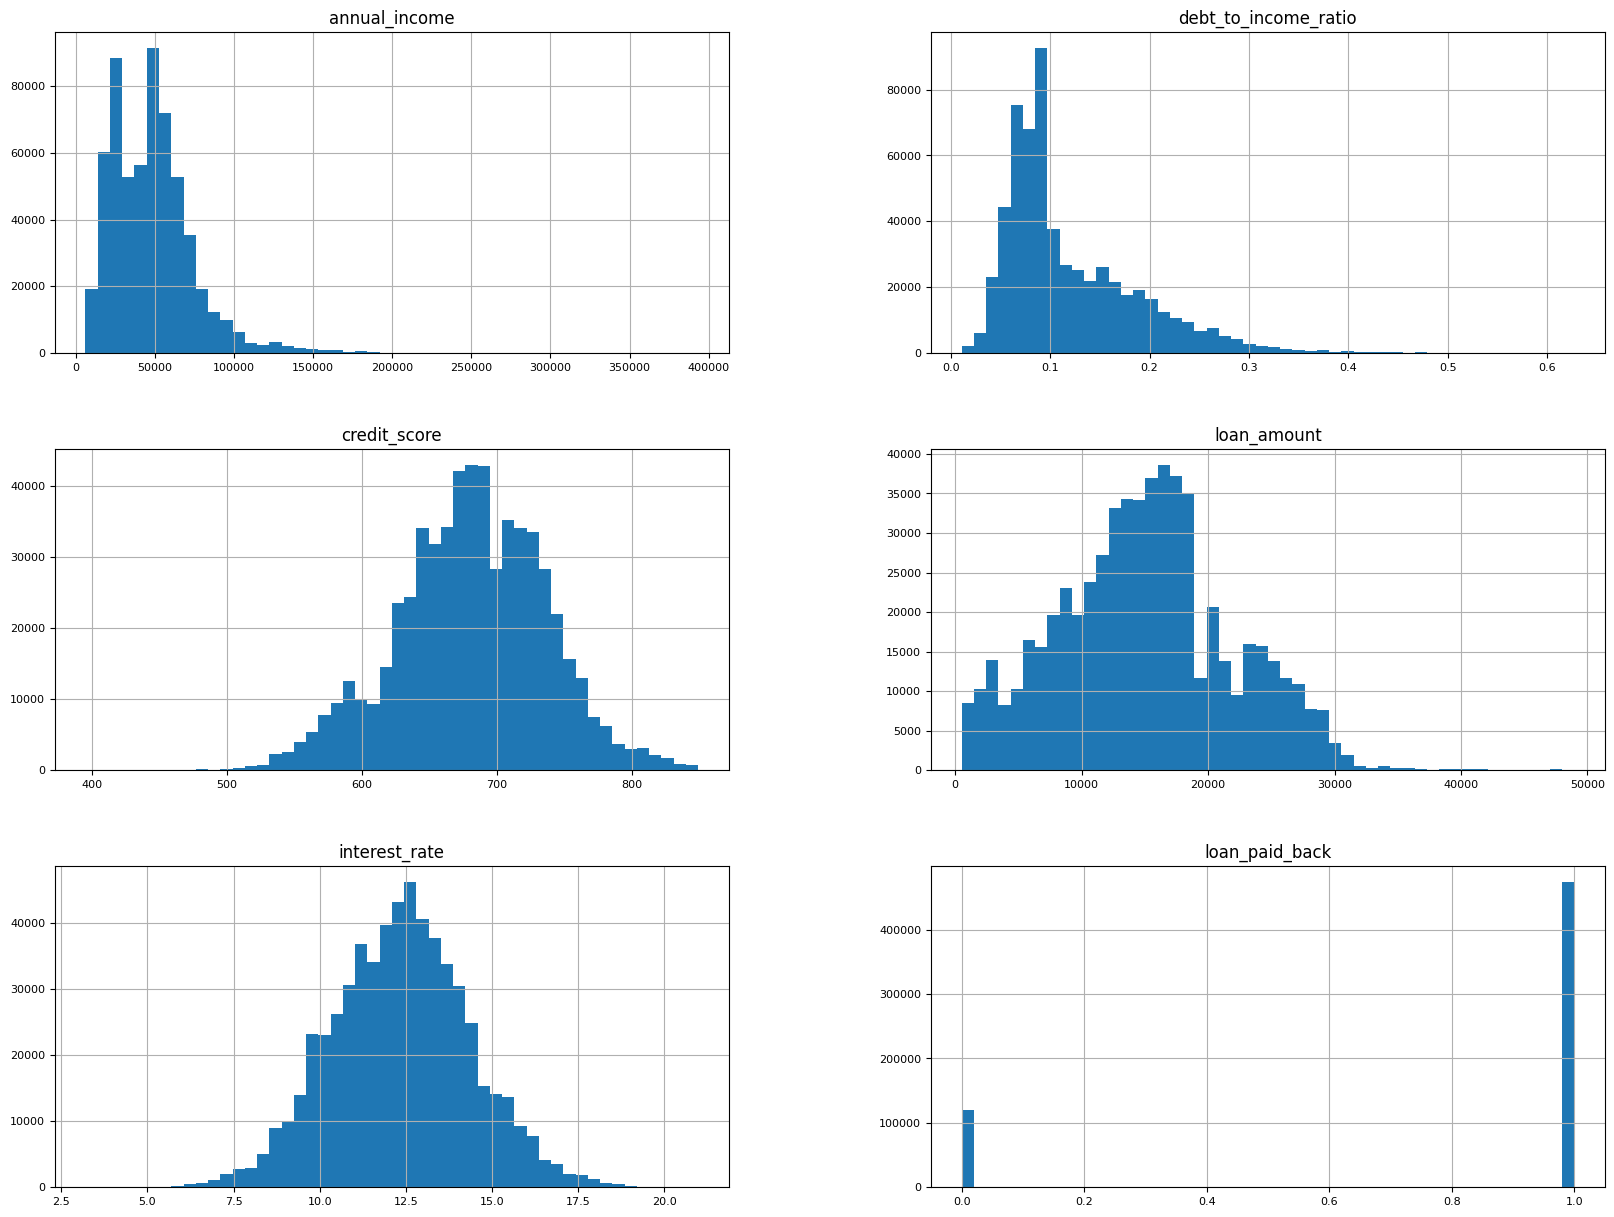

In [11]:
training_data.hist(figsize=(20, 15), bins=50, xlabelsize=8, ylabelsize=8)

<Axes: xlabel='employment_status', ylabel='count'>

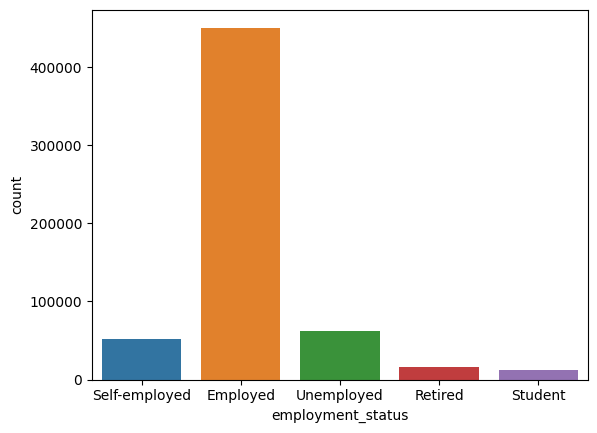

In [12]:
sns.countplot(data = training_data, x='employment_status')

/tmp/ipykernel_13/3125916017.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 3, plot_count+1)


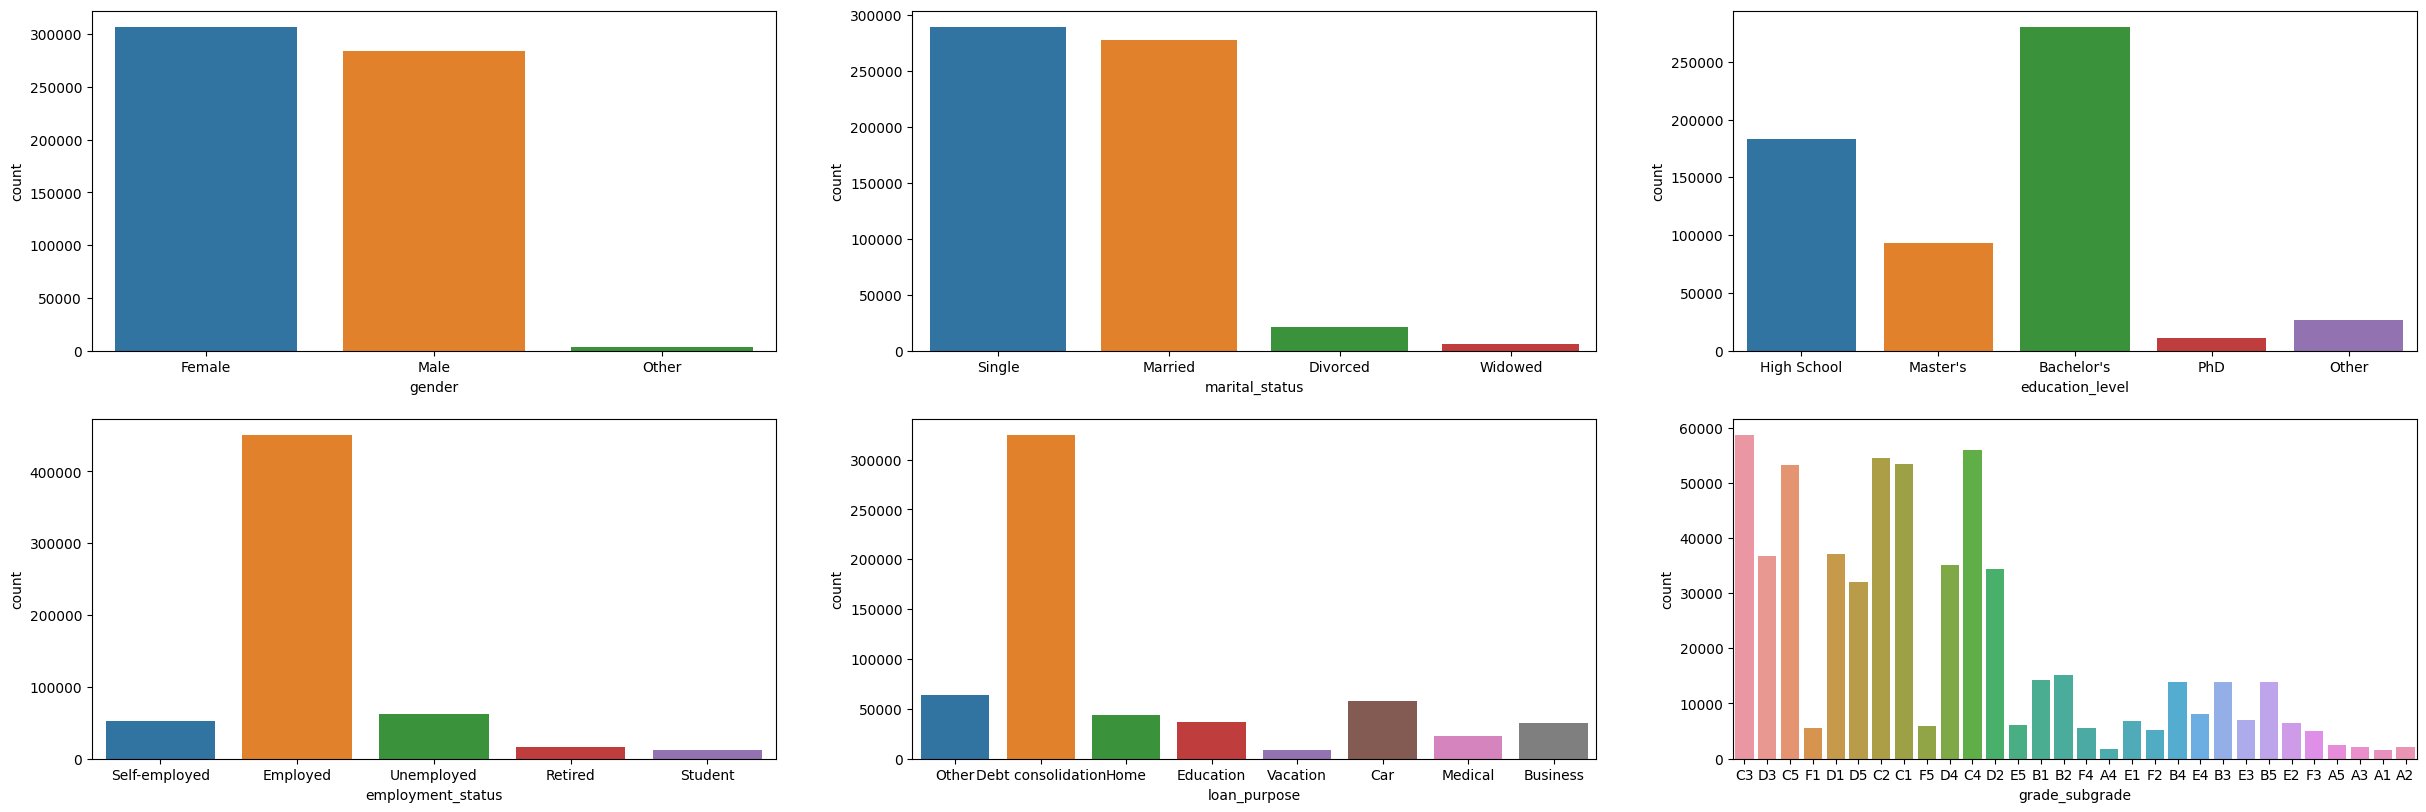

In [13]:
plt.figure(figsize=(30, 15))
plt.title("Categorical Feature Representation")
plot_count = 0
plt.axis("off")

categorical_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

for category in categorical_cols:
    ax = plt.subplot(3, 3, plot_count+1)
    sns.countplot(data=training_data, x=category)
    plot_count += 1

plt.show()

In [14]:
X = training_data.drop(columns= 'loan_paid_back')
y = training_data['loan_paid_back']

In [15]:
import random
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool

In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size=0.3, stratify=y)


In [17]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

numeric_transform = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

categorical_transform = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])

preprocessor = ColumnTransformer(transformers= [("num", numeric_transform, numeric_features), ("cat", categorical_transform, categorical_cols)])

In [18]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

X_valid_preprocessed = preprocessor.transform(X_valid)

In [19]:
# Determine categorical indices after ColumnTransformer
# Categorical features come after numeric in the transformed matrix
cat_indices_after_transform = list(range(len(numeric_features), len(numeric_features) + len(categorical_cols)))

In [20]:
# clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier",  LogisticRegression(random_state = 42, class_weight = "balanced"))])

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTENC(
        categorical_features= cat_indices_after_transform,
        random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose',
                                                   'grade_subgrade'])])),
                ('smote',
                 SMOTENC(categorical_features=[5, 6, 7, 8, 9, 10],
                         random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

In [21]:
predictions = clf.predict(X_train)

In [22]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve, auc

print("Train ROC", roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]))

Train ROC 0.8922364084266448


In [23]:
prediction_valid = clf.predict(X_valid)

In [24]:
print("Train ROC", roc_auc_score(y_valid, clf.predict_proba(X_valid)[:, 1]))

Train ROC 0.8916595577610426


### Plotting the ROC-AUC Curve for Logisitic Regression

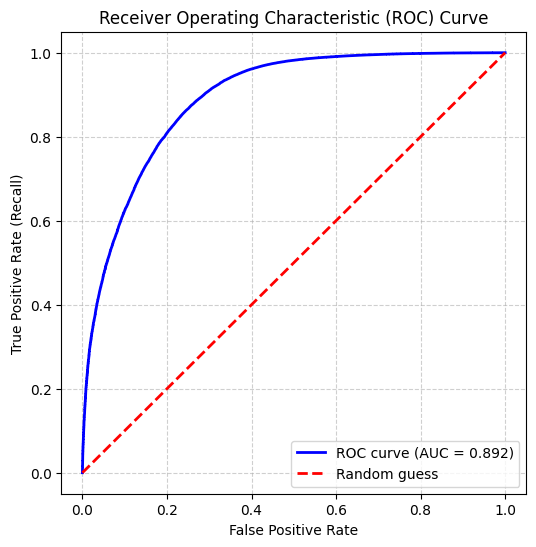

In [25]:
validation_prob = clf.predict_proba(X_valid)[:, 1]

#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_valid, validation_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Implementing CatBoost Pipeline

In [26]:
smote = SMOTENC(categorical_features = cat_indices_after_transform, random_state = 42)

X_train_resample, y_train_resample = smote.fit_resample(X_train_preprocessed, y_train)

train_pool = Pool(
    data=X_train_resample,
    label=y_train_resample
)

val_pool = Pool(
    data=X_valid_preprocessed,
    label=y_valid
)

In [27]:
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

In [28]:
model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

0:	test: 0.9001083	best: 0.9001083 (0)	total: 148ms	remaining: 3m 41s
200:	test: 0.9112164	best: 0.9113763 (151)	total: 16.6s	remaining: 1m 47s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9113762617
bestIteration = 151

Shrink model to first 152 iterations.


In [29]:
y_pred_proba = model.predict_proba(X_valid_preprocessed)[:, 1]

In [30]:
test_data = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv", index_col = 0)

In [31]:
test_data.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
id,,,,,,,,,,,
593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [32]:
test_predictions = clf.predict(test_data)
test_pred_prob = clf.predict_proba(test_data)[:, 1]

### Preprocessing test data to make predictions using CatBoost

In [33]:
X_test_preprocessed = preprocessor.transform(test_data)

test_pool = Pool(
    data=X_test_preprocessed
)


In [34]:
y_test_cat_prob = model.predict_proba(test_pool)[:, 1]

In [35]:
# submission_df = pd.DataFrame({'id': test_data.index, 'y': test_pred_prob})
submission_df = pd.DataFrame({'id': test_data.index, 'y': y_test_cat_prob})

In [36]:
submission_df.head()

,id,y
0,593994,0.792224
1,593995,0.937386
2,593996,0.173165
3,593997,0.780043
4,593998,0.904985


In [37]:
submission_df.to_csv("submission.csv", index=False)